In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, jaccard_score
from sklearn.compose import ColumnTransformer
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain

In [2]:
df = pd.read_csv('../all_20_output.csv')

C:\Users\hanna\AppData\Local\Temp\ipykernel_22424\498748741.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../all_20_output.csv')


In [3]:
df.columns

Index(['Filename', 'Period', 'Date', 'Speech #', 'Paragraph #', 'Speaker',
       'Role', 'Gender', 'Party', 'Paragraph', 'Interjection Text',
       'Interjection', 'Intervention', 'Quote', 'Interjector',
       'Interjector Gender', 'Interjector Party', 'Verbal interjection',
       'Nonverbal interjection', 'Interjection type', 'Directed at (Person)',
       'Directed at (Party)', 'Paragraph tokens', 'Interjection tokens',
       'paragraph_token_count', 'interjection_token_count', 'Agenda Item',
       'Context', 'Supplementary Context', 'Previous Interjections',
       'Previous Paragraphs'],
      dtype='object')

In [4]:
df_opposition = df[
    (df["Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (~df["Interjector Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (df["Interjection type"].isin(["Zuruf", "Zurufe"])) &
    (~df["Interjection Text"].isna()) &
    (df["Role"] != "Presidency")
]

In [5]:
df_sample = df_opposition.sample(n=100, random_state=42)

In [6]:
df_sample.to_csv("../opposition.csv", index=False)

In [7]:
df_coalition= df[
    (df["Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (df["Interjector Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (df["Interjection type"].isin(["Zuruf", "Zurufe"])) &
    (df["Role"] != "Presidency")
]

In [8]:
df_coalition_no_content = df[
    (df["Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (df["Interjector Party"].isin(["SPD", "GRUENE", "FDP"])) &
    (df["Interjection type"].isin(["Zuruf", "Zurufe"])) &
    (df["Interjection Text"].isna()) &
    (df["Role"] != "Presidency")
]

In [10]:
df_coalition

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Paragraph,...,Directed at (Party),Paragraph tokens,Interjection tokens,paragraph_token_count,interjection_token_count,Agenda Item,Context,Supplementary Context,Previous Interjections,Previous Paragraphs
1143,20_0002.xml,20,11.11.2021,3,7,Franziska Brantner,NaN,weiblich,GRUENE,"Sie spielen damit jenen in die Hände, die die ...",...,GRUENE,NaN,"['So', 'ist', 'es']",0,3,"Migration ordnen, steuern und begrenzen – Neue...",a) Beratung des Antrags der Fraktion der CDU/C...,NaN,[],"['Wir sind anders als Lukaschenko, und das müs..."
1485,20_0002.xml,20,11.11.2021,4,1,Till Mansmann,NaN,männlich,FDP,Sehr geehrte Frau Präsidentin! Geschätzte Koll...,...,FDP,NaN,['Wahnsinn'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[],[]
1490,20_0002.xml,20,11.11.2021,4,3,Till Mansmann,NaN,männlich,FDP,"2013 wurden die Wurzeln im BMF gelegt, das dam...",...,FDP,NaN,"['Guter', 'Geschichtsunterricht']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Beifall', 'FDP', None)]",['Sehr geehrte Frau Präsidentin! Geschätzte Ko...
1492,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,In aller Kürze: Wir müssen das jetzt in letzte...,...,FDP,NaN,['Richtig'],0,1,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,[],['und das sich über die letzte Legislaturperio...
1493,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,In aller Kürze: Wir müssen das jetzt in letzte...,...,FDP,NaN,"['Genau', 'Richtig']",0,2,NaN,Erste Beratung des von der Bundesregierung ein...,NaN,"[('Zuruf', 'SPD', 'Richtig!')]",['und das sich über die letzte Legislaturperio...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721752,20_0214.xml,20,18.03.2025,32,3,Jessica Rosenthal,NaN,weiblich,SPD,"Ich war fassungslos, dass Sie von der Union un...",...,SPD,NaN,[],0,0,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[],['Sehr geehrte Frau Präsidentin! Sehr geehrte ...
721760,20_0214.xml,20,18.03.2025,32,7,Jessica Rosenthal,NaN,weiblich,SPD,Das heißt aus meiner Sicht vor allem Bildung. ...,...,SPD,NaN,"['Dann', 'gehen', 'Sie', 'in', 'den', 'Landtag']",0,6,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[],"['Angesichts all der Herausforderungen, vor de..."
721870,20_0214.xml,20,18.03.2025,37,8,Dennis Rohde,NaN,männlich,SPD,"Liebe Kolleginnen und Kollegen, wir reformiere...",...,SPD,NaN,['Schleifen'],0,1,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,"[('Beifall', 'SPD', None), ('Zuruf', 'AfD', 'I...","['Wer jetzt noch glaubt, dass Stillstand die s..."
721882,20_0214.xml,20,18.03.2025,37,15,Dennis Rohde,NaN,männlich,SPD,"Lassen Sie uns heute, liebe Kolleginnen und Ko...",...,SPD,NaN,"['Zu', 'Schulden']",0,2,Nein zur Kriegstüchtigkeit – Ja zur Diplomatie...,a) Zweite und dritte Beratung des von den Frak...,NaN,[],"['Weil das so ist, braucht eine wehrhafte Demo..."


In [14]:
print(f"No interjection content in about {len(df_coalition_no_content) / len(df_coalition) * 100}% of cases")

No interjection content in about 8.633207070707071% of cases


In [ ]:
# start with actual model

In [3]:
annotations = pd.read_csv('../annotations/final_labels_rq2.csv')

In [19]:
# remove party information, turn labels into lists for multilabel classifier
annotations["Interjection Label Party"] = annotations["Interjection Label"]
annotations["Interjection Label"] = annotations["Interjection Label"].apply(
    lambda x: ", ".join(
        {
            "_".join(part.strip().split("_")[:-1])
            if part.strip().count("_") >= 2
            else part.strip()
            for part in x.split(",")
        }
    )
)
annotations["Interjection Label List"] = annotations["Interjection Label"].apply(
    lambda x: [s.strip() for s in x.split(",")])

In [20]:
### Preprocessing

X = pd.DataFrame({
    "Interjection Text": annotations["Interjection Text"],
    "Paragraph": annotations["Paragraph"],
    "Directed at (Party)": annotations["Directed at (Party)"],
    "Party": annotations["Party"],
    "Interjector Party": annotations["Interjector Party"],
    "Quote": annotations["Quote"]
})

y = annotations["Interjection Label List"].to_list()

In [21]:
X.columns

Index(['Interjection Text', 'Paragraph', 'Directed at (Party)', 'Party',
       'Interjector Party', 'Quote'],
      dtype='object')

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
label_series = pd.Series(y_train)

# Count per class
print(label_series.value_counts())

# Percentage per class
print(label_series.value_counts(normalize=True) * 100)

[cooperative]                                                    2326
[cooperative, confrontational_others]                             989
[confrontational]                                                 744
[confrontational_others]                                          336
[ambiguous]                                                       190
[cooperative_others]                                               18
[cooperative_others, confrontational]                               8
[cooperative_others, cooperative]                                   8
[confrontational, confrontational_others]                           6
[cooperative_others, confrontational, confrontational_others]       1
Name: count, dtype: int64
[cooperative]                                                    50.281020
[cooperative, confrontational_others]                            21.379161
[confrontational]                                                16.083009
[confrontational_others]                         

In [24]:
# Flatten the list of lists
all_labels = list(chain.from_iterable(y_train))

# Count each individual label
label_counts = Counter(all_labels)
print(label_counts)

Counter({'cooperative': 3323, 'confrontational_others': 1332, 'confrontational': 759, 'ambiguous': 190, 'cooperative_others': 35})


In [25]:
### baseline without any special features, just the interjection text

In [36]:
### binarize multi labels
mlb = MultiLabelBinarizer()
y_train_binary = mlb.fit_transform(y_train)
y_test_binary = mlb.transform(y_test)

# Tf-IDF Vectorizer on interjection texts
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train["Interjection Text"])
X_test_tfidf = vectorizer.transform(X_test["Interjection Text"])

In [27]:
joblib.dump(mlb, "interjection_type_mlb.joblib")

['interjection_type_mlb.joblib']

In [43]:
# TRAIN the classifier
classifier = OneVsRestClassifier(LinearSVC(class_weight='balanced'))

classifier.fit(X_train_tfidf, y_train_binary)

OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced'))

In [44]:
y_pred_binary = classifier.predict(X_test_tfidf)
print(
    classification_report(
        y_test_binary,
        y_pred_binary,
        target_names=mlb.classes_,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

             ambiguous       0.14      0.26      0.18        54
       confrontational       0.47      0.74      0.57       193
confrontational_others       0.61      0.74      0.67       331
           cooperative       0.89      0.81      0.85       826
    cooperative_others       0.05      0.33      0.09         6

             micro avg       0.67      0.76      0.71      1410
             macro avg       0.43      0.58      0.47      1410
          weighted avg       0.74      0.76      0.74      1410
           samples avg       0.72      0.78      0.73      1410



In [45]:
empty_rows = np.where(y_pred_binary.sum(axis=1) == 0)[0]

# Find index of "ambiguous" in mlb.classes_
amb_idx = np.where(mlb.classes_ == "ambiguous")[0][0]

# Set those rows to all zeros except ambiguous = 1
y_pred_binary[empty_rows, :] = 0
y_pred_binary[empty_rows, amb_idx] = 1

In [46]:
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=mlb.classes_,
    zero_division=0
))

                        precision    recall  f1-score   support

             ambiguous       0.13      0.26      0.17        54
       confrontational       0.47      0.74      0.57       193
confrontational_others       0.61      0.74      0.67       331
           cooperative       0.89      0.81      0.85       826
    cooperative_others       0.05      0.33      0.09         6

             micro avg       0.67      0.76      0.71      1410
             macro avg       0.43      0.58      0.47      1410
          weighted avg       0.74      0.76      0.74      1410
           samples avg       0.72      0.78      0.73      1410



In [13]:
###  add features: paragraph (tf-idf), directed_at != speaker true or false, party != interjector party true or false, quote true or false

In [15]:
class BooleanFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, include=True):
        self.include = include
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if self.include:
            return np.column_stack([
                (X["Directed at (Party)"] != X["Party"]).astype(int),
                (X["Party"] != X["Interjector Party"]).astype(int),
                (X["Quote"]).astype(int)
            ])
        else:
            return np.zeros((X.shape[0], 2))

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        # Main text TF-IDF
        ("tfidf_interjection", TfidfVectorizer(), "Interjection Text"),
        # Paragraph TF-IDF
        ("tfidf_paragraph", TfidfVectorizer(), "Paragraph"),
        # Boolean features
        ("bools", BooleanFeatures(), ["Directed at (Party)", "Party", "Interjector Party", "Quote"]),
    ],
    remainder="drop"
)


In [17]:
pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", OneVsRestClassifier(
        LinearSVC(class_weight='balanced')
    )),
])

In [18]:
param_grid = {
    # Interjection Text TF-IDF tuning
    "features__tfidf_interjection__ngram_range": [(1,1),(1,2)],
    "features__tfidf_interjection__min_df": [1,4],

    # Paragraph TF-IDF tuning
    "features__tfidf_paragraph__ngram_range": [(1,1),(1,2)],
    "features__tfidf_paragraph__min_df": [1,4],

    # Boolean features: include or skip
    "features__bools": [BooleanFeatures(include=False), BooleanFeatures(include=True)],

    # LinearSVC regularization (C)
    "clf__estimator__C": [0.1,1,10]
}


grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_micro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train_binary)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('features',
                                        ColumnTransformer(transformers=[('tfidf_interjection',
                                                                         TfidfVectorizer(),
                                                                         'Interjection '
                                                                         'Text'),
                                                                        ('tfidf_paragraph',
                                                                         TfidfVectorizer(),
                                                                         'Paragraph'),
                                                                        ('bools',
                                                                         BooleanFeatures(),
                                                                         ['Directed '
                                                                          'at '
                                                                          '(Party)',
                                                                          'Party',
                                                                          'Interjector '
                                                                          'Party',
                                                                          'Quote'])])),
                                       ('clf',
                                        OneVsRestClassifier(estimator=LinearSVC(class_wei...
             n_jobs=-1,
             param_grid={'clf__estimator__C': [0.1, 1, 10],
                         'features__bools': [BooleanFeatures(include=False),
                                             BooleanFeatures()],
                         'features__tfidf_interjection__min_df': [1, 4],
                         'features__tfidf_interjection__ngram_range': [(1, 1),
                                                                       (1, 2)],
                         'features__tfidf_paragraph__min_df': [1, 4],
                         'features__tfidf_paragraph__ngram_range': [(1, 1),
                                                                    (1, 2)]},
             scoring='f1_micro', verbose=2)

In [19]:
print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'clf__estimator__C': 10, 'features__bools': BooleanFeatures(), 'features__tfidf_interjection__min_df': 1, 'features__tfidf_interjection__ngram_range': (1, 2), 'features__tfidf_paragraph__min_df': 1, 'features__tfidf_paragraph__ngram_range': (1, 2)}
Best CV score: 0.8133829671542264


In [20]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Best params:")
print(grid.best_params_)

print(classification_report(
    y_test_binary,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))


Best params:
{'clf__estimator__C': 10, 'features__bools': BooleanFeatures(), 'features__tfidf_interjection__min_df': 1, 'features__tfidf_interjection__ngram_range': (1, 2), 'features__tfidf_paragraph__min_df': 1, 'features__tfidf_paragraph__ngram_range': (1, 2)}
                        precision    recall  f1-score   support

             ambiguous       0.44      0.07      0.13        54
       confrontational       0.73      0.74      0.73       193
confrontational_others       0.76      0.74      0.75       331
           cooperative       0.90      0.90      0.90       826
    cooperative_others       0.50      0.17      0.25         6

             micro avg       0.84      0.80      0.82      1410
             macro avg       0.67      0.52      0.55      1410
          weighted avg       0.82      0.80      0.81      1410
           samples avg       0.80      0.81      0.79      1410



In [21]:
empty_rows = np.where(y_pred.sum(axis=1) == 0)[0]

# Find index of "ambiguous" in mlb.classes_
amb_idx = np.where(mlb.classes_ == "ambiguous")[0][0]

# Set those rows to all zeros except ambiguous = 1
y_pred[empty_rows, :] = 0
y_pred[empty_rows, amb_idx] = 1

In [22]:
print(classification_report(
    y_test_binary,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

                        precision    recall  f1-score   support

             ambiguous       0.16      0.28      0.21        54
       confrontational       0.73      0.74      0.73       193
confrontational_others       0.76      0.74      0.75       331
           cooperative       0.90      0.90      0.90       826
    cooperative_others       0.50      0.17      0.25         6

             micro avg       0.80      0.81      0.80      1410
             macro avg       0.61      0.56      0.57      1410
          weighted avg       0.81      0.81      0.81      1410
           samples avg       0.81      0.82      0.80      1410



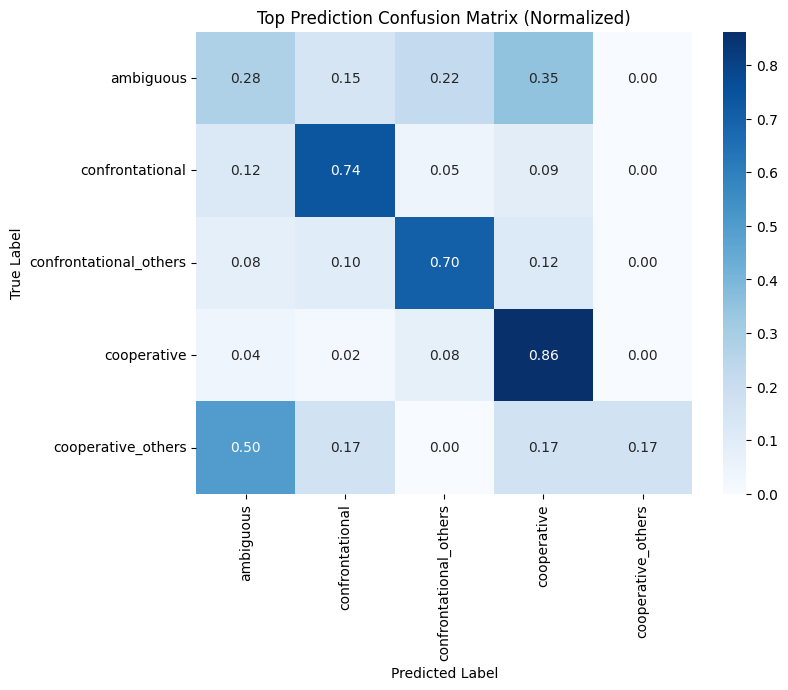

In [24]:
# y_test_binary and y_pred are (n_samples, n_classes)
top_true = np.argmax(y_test_binary, axis=1)
top_pred = np.argmax(y_pred, axis=1)

# Get class names
classes = mlb.classes_

confusion_top = pd.crosstab(
    top_true,
    top_pred,
    rownames=['True Label'],
    colnames=['Predicted Label'],
    normalize='index'
)

# Replace integer indices with class names
confusion_top.index = classes
confusion_top.columns = classes
plt.figure(figsize=(8,6))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [25]:
true_label_list = [
    list(mlb.classes_[y_test_binary[i].astype(bool)])
    for i in range(y_test_binary.shape[0])
]

pred_label_list = [
    list(mlb.classes_[y_pred[i].astype(bool)])
    for i in range(y_pred.shape[0])
]

X_test_with_labels = X_test.copy()
X_test_with_labels["true_label"] = true_label_list
X_test_with_labels["pred_label"] = pred_label_list

X_test_with_labels.to_csv("error_analysis_interjection.csv", index=False)


In [26]:
label_counts = np.sum(y_train_binary, axis=0)  # sum per column (per class)
label_distribution = pd.DataFrame({
    "class": mlb.classes_,
    "count": label_counts
}).sort_values(by="count", ascending=False)

print(label_distribution)

                    class  count
3             cooperative   3323
2  confrontational_others   1332
1         confrontational    759
0               ambiguous    190
4      cooperative_others     35


In [27]:
# final training

In [ ]:
# Combine all data (train + test)
X_final = pd.concat([X_train, X_test], axis=0)
y_final = np.vstack([y_train_binary, y_test_binary])

# --- Set TF-IDF hyperparameters ---
preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf_interjection", TfidfVectorizer(ngram_range=(1,2), min_df=1), "Interjection Text"),
        ("tfidf_paragraph", TfidfVectorizer(ngram_range=(1,2), min_df=1), "Paragraph"),
        ("bools", BooleanFeatures(), ["Directed at (Party)", "Party", "Interjector Party", "Quote"]),
    ],
    remainder="drop"
)

# --- Final pipeline ---
final_pipeline = Pipeline([
    ("features", preprocessor),
    ("clf", OneVsRestClassifier(LinearSVC(class_weight='balanced', C=10, max_iter=5000)))
])
# Fit on all data
final_pipeline.fit(X_final, y_final)

# Save for inference
joblib.dump(final_pipeline, "interjection_type_svm_pipeline.joblib")
